Importaciones de librerias

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

1.- Tratamiento de datos categoricos:

In [20]:
# Cargar el dataset con el separador correcto
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Separar y guardar únicamente las variables categóricas en un DataFrame nuevo
df_cat = df.select_dtypes(include=['object', 'category']).copy()

# Rellenar los valores 'unknown' con la moda de cada columna
for col in df_cat.columns:
    moda = df_cat[col].mode()[0]
    df_cat[col] = df_cat[col].replace('unknown', moda)

# Aplicar codificación One-Hot Encoding (dejando en formato entero numérico)
df_encoded = pd.get_dummies(df_cat, drop_first=True, dtype=int)

# Verificación rápida del resultado
print(df_encoded.head())

   job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0                0                 0              1               0   
1                0                 0              0               0   
2                0                 0              0               0   
3                0                 0              0               0   
4                0                 0              0               0   

   job_retired  job_self-employed  job_services  job_student  job_technician  \
0            0                  0             0            0               0   
1            0                  0             1            0               0   
2            0                  0             1            0               0   
3            0                  0             0            0               0   
4            0                  0             1            0               0   

   job_unemployed  ...  month_nov  month_oct  month_sep  day_of_week_mon  \
0               

In [21]:
df_encoded

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,y_yes
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
41184,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
41185,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
41186,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,1,0,1


2.- Tratamiento de outliers

Total de filas recibidas sin winsorizar de la Sección 1: 41188


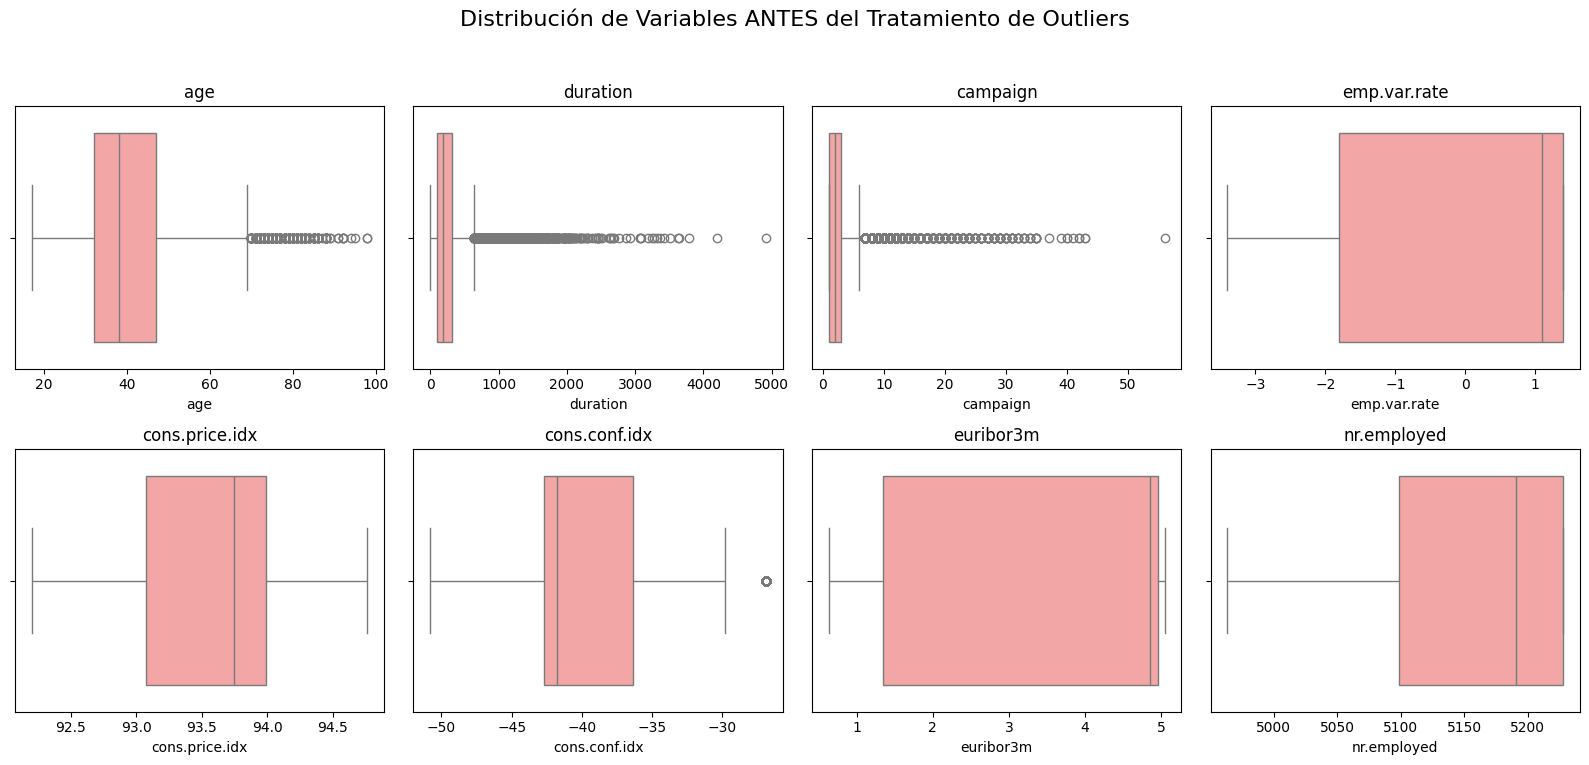

--------------------------------------------------
REPORTE DE VALORES ATÍPICOS AJUSTADOS:
- age: 469 valores ajustados
- duration: 2963 valores ajustados
- campaign: 2406 valores ajustados
- emp.var.rate: 0 valores ajustados
- cons.price.idx: 0 valores ajustados
- cons.conf.idx: 447 valores ajustados
- euribor3m: 0 valores ajustados
- nr.employed: 0 valores ajustados

Total de filas winsorizadas: 34903
--------------------------------------------------


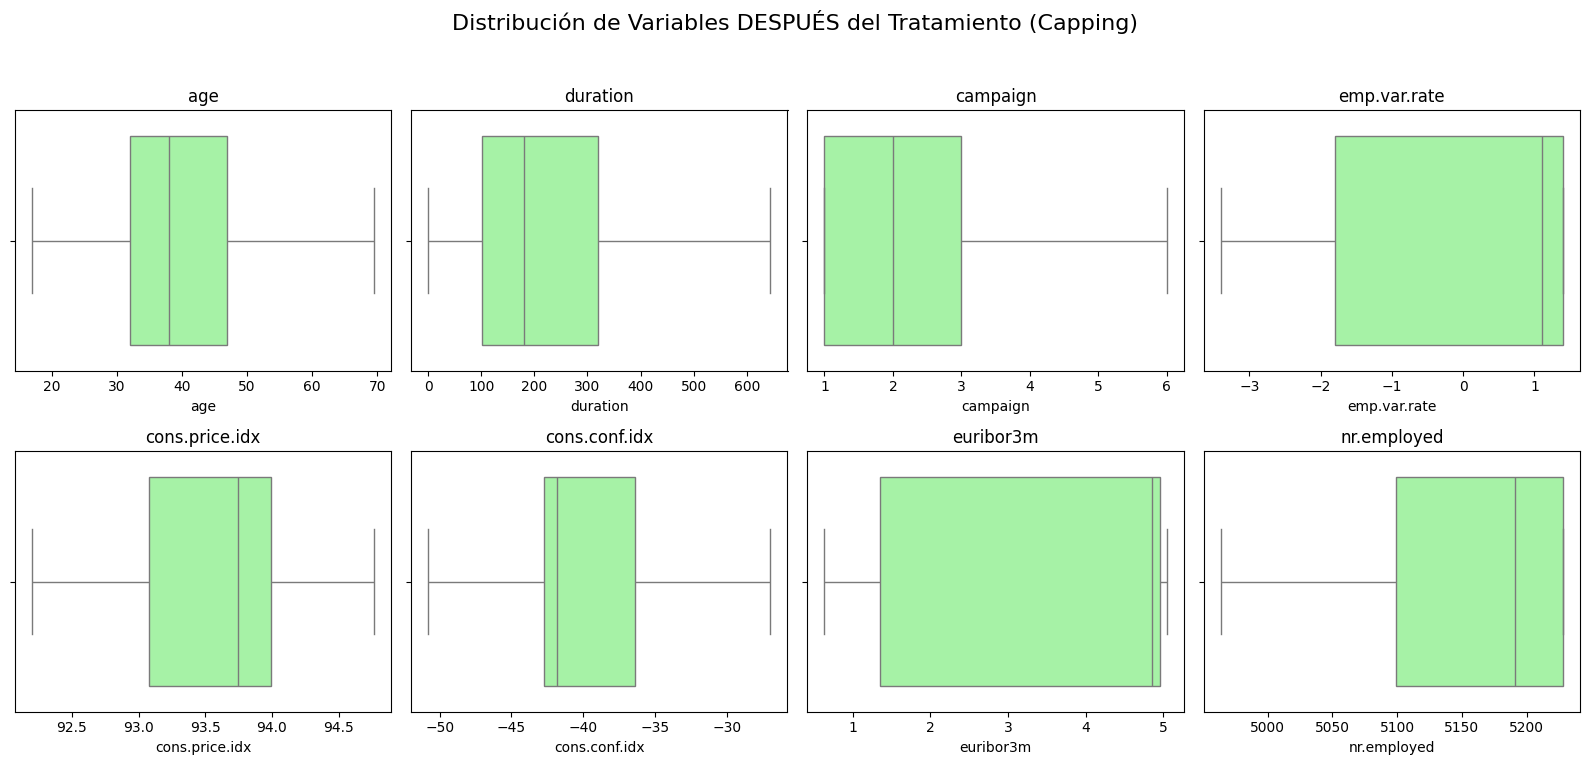

In [22]:
# 1. Registro del estado inicial
filas_iniciales = len(df)
print(f"Total de filas recibidas sin winsorizar de la Sección 1: {filas_iniciales}")

# Definimos las columnas numéricas relevantes para el análisis de outliers
# Nota: Excluimos pdays porque 999 es un valor centinela, no un outlier numérico real.
cols_num = ['age', 'duration', 'campaign', 'emp.var.rate', 
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# 2. Visualización inicial (Antes de limpiar)
plt.figure(figsize=(16, 8))
plt.suptitle('Distribución de Variables ANTES del Tratamiento de Outliers', fontsize=16)
for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[col], color='#ff9999') # Rojo suave para indicar "sucio"
    plt.title(col)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. Identificación y tratamiento mediante Capping (Topado)
# Usamos Capping en lugar de eliminar filas para no perder información valiosa de otras columnas.
resumen_outliers = {}

for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántos valores están fuera de los límites
    fuera_de_rango = df[(df[col] < limite_inferior) | (df[col] > limite_superior)].shape[0]
    resumen_outliers[col] = fuera_de_rango
    
    # Aplicamos el capping directamente en el DataFrame
    df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)

# 4. Reporte de resultados

print("-" * 50)
print("REPORTE DE VALORES ATÍPICOS AJUSTADOS:")
for col, cant in resumen_outliers.items():
    print(f"- {col}: {cant} valores ajustados")
cantidad_ajustada = sum(resumen_outliers.values())    
filas_finales=len(df)-cantidad_ajustada
print(f"\nTotal de filas winsorizadas: {filas_finales}")
print("-" * 50)

# 5. Visualización final (Después de limpiar)
plt.figure(figsize=(16, 8))
plt.suptitle('Distribución de Variables DESPUÉS del Tratamiento (Capping)', fontsize=16)
for i, col in enumerate(cols_num, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[col], color='#99ff99') # Verde suave para indicar "limpio"
    plt.title(col)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Identificación y Eliminación de Variables Irrelevantes

Según la documentación técnica, la variable duration es altamente predictiva pero irrelevante para un modelo realista, ya que solo se conoce después de que la llamada termina. Mantenerla sería una falta de ética profesional y técnica

In [23]:
# Verificamos la presencia de la variable antes de eliminarla
print(f"Columnas originales: {df.shape[1]}")

# Eliminamos 'duration' por integridad del modelo y ética en los datos
df = df.drop(columns=['duration'])

# Eliminamos 'mora' (default) ya que menos del 0.01% de los datos tiene como "sí", haciéndolo irrelevante
df = df.drop(columns=['default'])

# Justificación: Un modelo realista no puede usar información que no existe 
# antes de la toma de decisión (realizar la llamada).
print(f"Columnas después de la limpieza: {df.shape[1]}")

Columnas originales: 21
Columnas después de la limpieza: 19


#### Escalamiento de Variables numéricas

Se utiliza StandardScaler para transformar las variables numéricas de modo que tengan una media de 0 y una desviación estándar de 1. Esto asegura que variables con rangos grandes (como nr.employed) no dominen injustamente sobre variables con rangos pequeños (como euribor3m) durante el entrenamiento del modelo.

In [24]:
# Definimos las columnas numéricas que requieren escalamiento
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Inicializamos el escalador estándar
scaler = StandardScaler()

# Aplicamos el escalamiento y sobreescribimos en el dataframe
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Mostramos los resultados escalados (ahora centrados en 0)
df[numeric_cols].head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,1.585559,-0.822497,0.195414,-0.349494,0.648092,0.722722,0.886869,0.71246,0.33168
1,1.684283,-0.822497,0.195414,-0.349494,0.648092,0.722722,0.886869,0.71246,0.33168
2,-0.290198,-0.822497,0.195414,-0.349494,0.648092,0.722722,0.886869,0.71246,0.33168
3,0.005974,-0.822497,0.195414,-0.349494,0.648092,0.722722,0.886869,0.71246,0.33168
4,1.585559,-0.822497,0.195414,-0.349494,0.648092,0.722722,0.886869,0.71246,0.33168


#### Verificación de la Integridad de datos


In [25]:
# Resumen estadístico post-escalamiento para confirmar media ~ 0 y std ~ 1
df[numeric_cols].describe().round(2)

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.26,-0.82,-5.15,-0.35,-2.22,-2.37,-2.23,-1.72,-2.82
25%,-0.78,-0.82,0.20,-0.35,-1.20,-0.86,-0.47,-1.31,-0.94
50%,-0.19,-0.18,0.20,-0.35,0.65,0.30,-0.28,0.71,0.33
75%,0.70,0.47,0.20,-0.35,0.84,0.72,0.89,0.77,0.85
max,2.92,2.40,0.20,13.79,0.84,2.06,2.93,0.82,0.85
